In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
df = pd.read_csv(r"C:\Users\akash\Downloads\Customer Behaviour analysis\customer_dataet.csv")

In [5]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [17]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [105]:
cat_cols = df.select_dtypes(include=['object', 'category'])
cat_value_counts = {
    col: cat_cols[col].value_counts()
    for col in cat_cols.columns
}

cat_value_counts

{'Gender': Gender
 Male      2652
 Female    1248
 Name: count, dtype: int64,
 'Item Purchased': Item Purchased
 Blouse        171
 Jewelry       171
 Pants         171
 Shirt         169
 Dress         166
 Sweater       164
 Jacket        163
 Belt          161
 Sunglasses    161
 Coat          161
 Sandals       160
 Socks         159
 Skirt         158
 Shorts        157
 Scarf         157
 Hat           154
 Handbag       153
 Hoodie        151
 Shoes         150
 T-shirt       147
 Sneakers      145
 Boots         144
 Backpack      143
 Gloves        140
 Jeans         124
 Name: count, dtype: int64,
 'Category': Category
 Clothing       1737
 Accessories    1240
 Footwear        599
 Outerwear       324
 Name: count, dtype: int64,
 'Location': Location
 Montana           96
 California        95
 Idaho             93
 Illinois          92
 Alabama           89
 Minnesota         88
 Nebraska          87
 New York          87
 Nevada            87
 Maryland          86
 Delaware

In [19]:
df['Subscription Status'].value_counts()

Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

### AGE

   Gender        Age
0  Female  44.007212
1    Male  44.097285


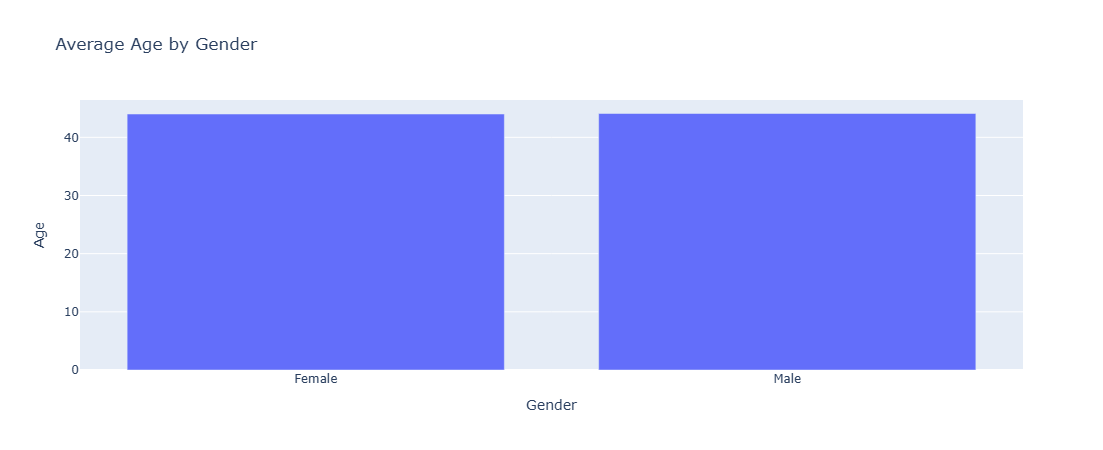

In [46]:
avg_age_gen = df.groupby(['Gender'])['Age'].mean().reset_index()
print(avg_age_gen)
px.bar(
    avg_age_gen,
    x='Gender',
    y='Age',
    title='Average Age by Gender',
    width=600,     # custom width
    height=450     # custom height
)

  Frequency of Purchases        Age
0               Annually  44.666084
1              Bi-Weekly  43.201097
2         Every 3 Months  43.407534
3            Fortnightly  43.586716
4                Monthly  44.283906
5              Quarterly  44.685613
6                 Weekly  44.649351


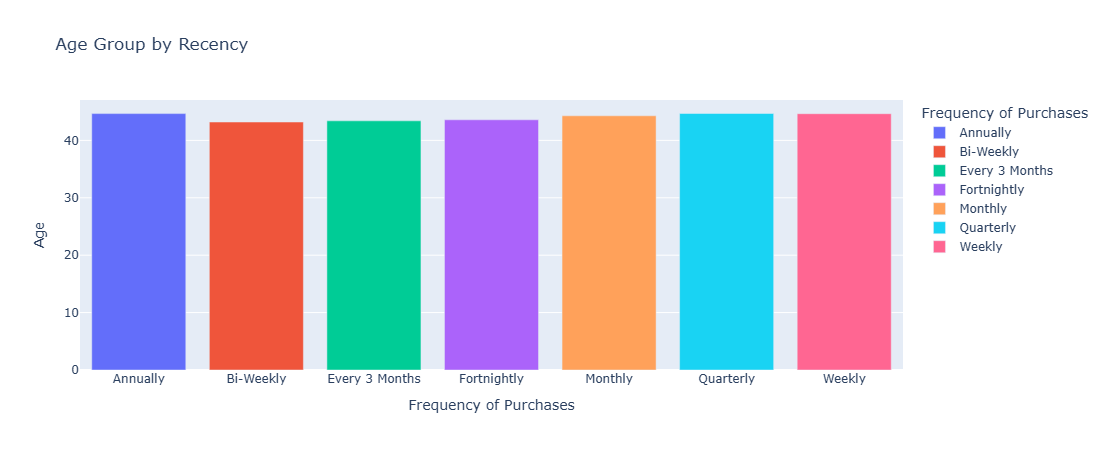

In [78]:
avg_age_Recency = df.groupby(['Frequency of Purchases'])['Age'].mean().reset_index()
print(avg_age_Recency)
px.bar(
    avg_age_Recency,
    x='Frequency of Purchases',
    y='Age',
    title='Age Group by Recency',
    width=600,     # custom width
    height=450,
    color= 'Frequency of Purchases'
)

      Category        Age
0  Accessories  44.224194
1     Clothing  43.782959
2     Footwear  44.442404
3    Outerwear  44.311728


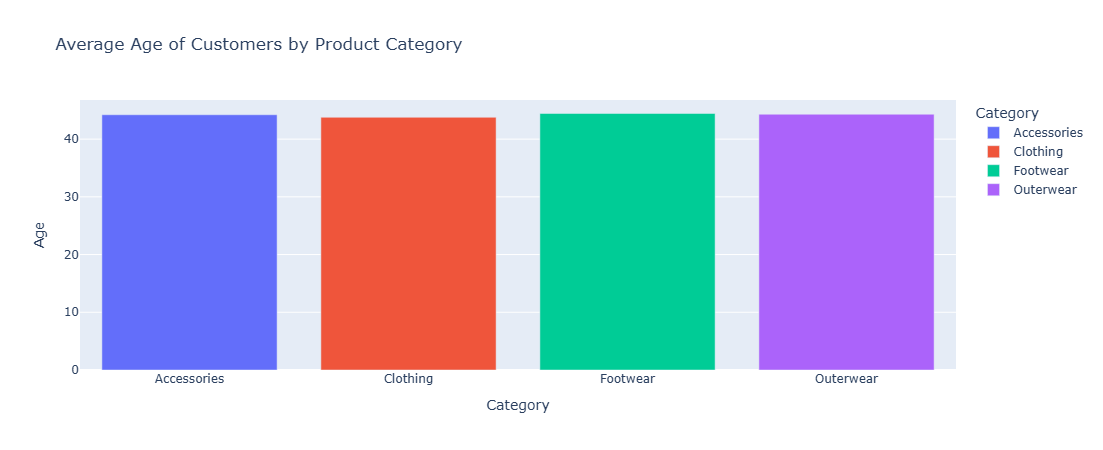

In [76]:
avg_age_Cate = df.groupby(['Category'])['Age'].mean().reset_index()
print(avg_age_Cate)
px.bar(
    avg_age_Cate,
    x='Category',
    y='Age',
    title='Average Age of Customers by Product Category',
    width=800,
    height=450,
    color ='Category'
)

  Subscription Status        Age
0                  No  44.008430
1                 Yes  44.230769


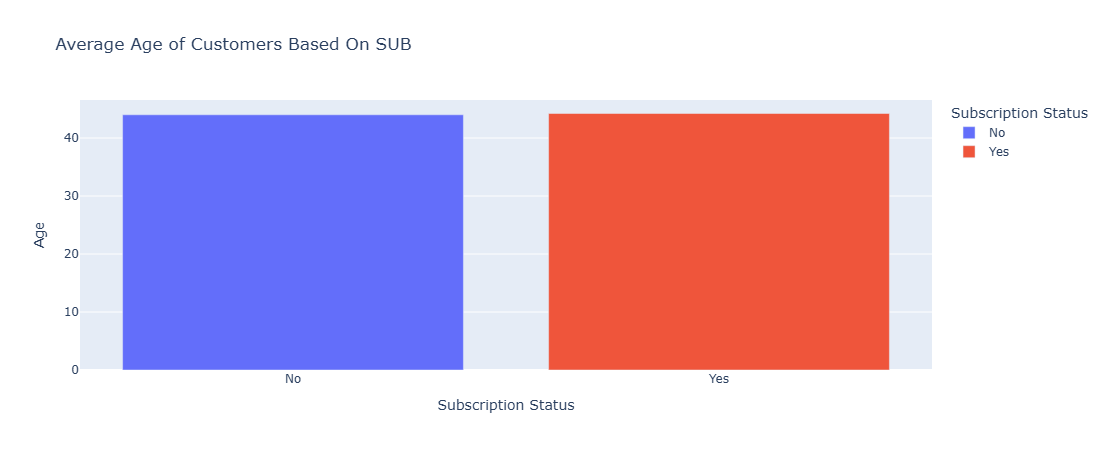

In [93]:
avg_age_SUB = df.groupby(['Subscription Status'])['Age'].mean().reset_index()
print(avg_age_SUB)
px.bar(
    avg_age_SUB,
    x='Subscription Status',
    y='Age',
    title='Average Age of Customers Based On SUB',
    width=800,
    height=450,
    color ='Subscription Status'
)

## AVG Purchase amount by Gender

   Gender  Purchase Amount (USD)
0  Female                  75191
1    Male                 157890


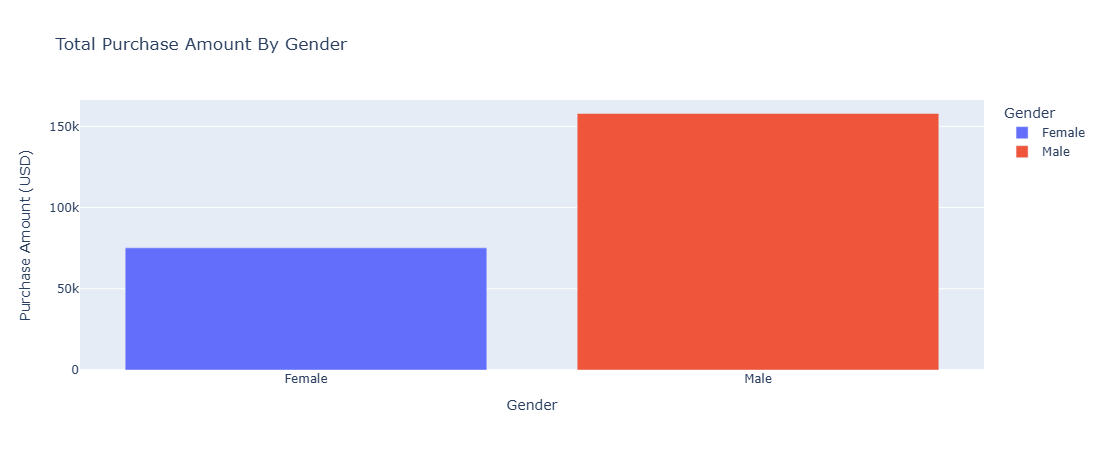

In [97]:
avg_amount_gen = df.groupby(['Gender'])['Purchase Amount (USD)'].sum().reset_index()
print(avg_amount_gen)
px.bar(
    avg_amount_gen,
    x='Gender',
    y='Purchase Amount (USD)',
    title='Total Purchase Amount By Gender',
    width=800,
    height=450,
    color ='Gender'
)

In [109]:
most_bought_category = (
    df.groupby(['Season', 'Category'])
      .size()
      .reset_index(name='count')
      .sort_values(['Season', 'count'], ascending=[True, False])
      .drop_duplicates(subset='Season')
)

most_bought_category



,Season,Category,count
1,Fall,Clothing,427
5,Spring,Clothing,454
9,Summer,Clothing,408
13,Winter,Clothing,448


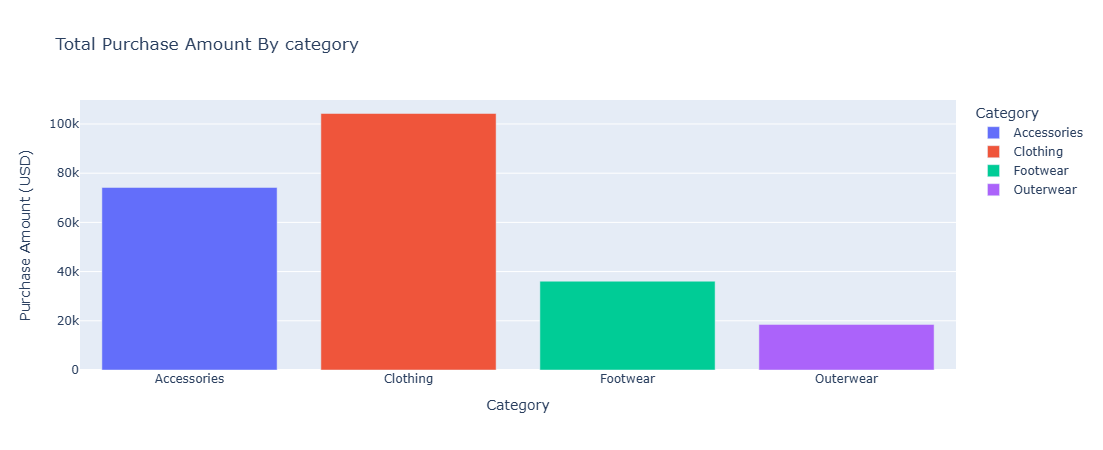

In [119]:
total_purchase_amount= df.groupby(['Category'])['Purchase Amount (USD)'].sum().reset_index()
total_purchase_amount
px.bar(
    total_purchase_amount,
    x='Category',
    y='Purchase Amount (USD)',
    title='Total Purchase Amount By category',
    width=800,
    height=450,
    color ='Category'
)

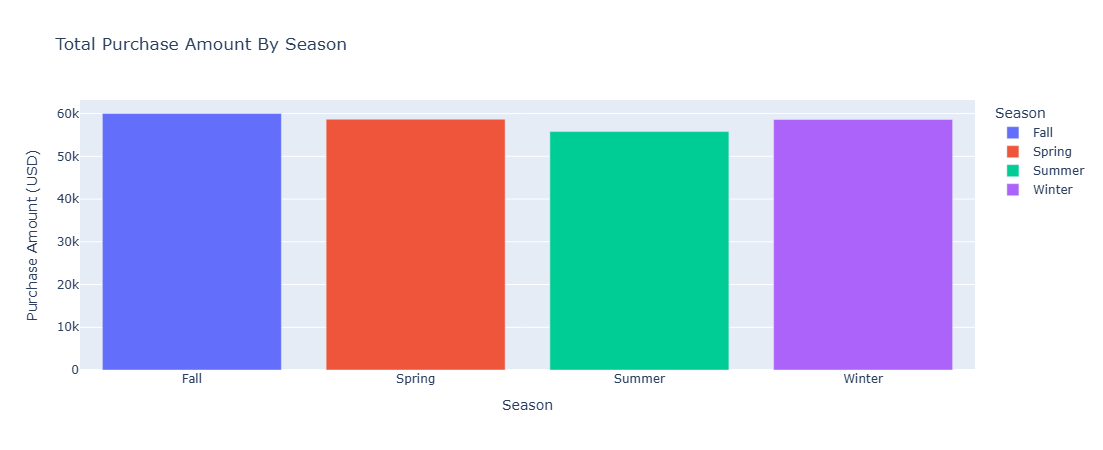

In [117]:
total_purchase_season = df.groupby(['Season'])['Purchase Amount (USD)'].sum().reset_index()
px.bar(
    total_purchase_season,
    x='Season',
    y='Purchase Amount (USD)',
    title='Total Purchase Amount By Season',
    width=800,
    height=450,
    color ='Season'
)

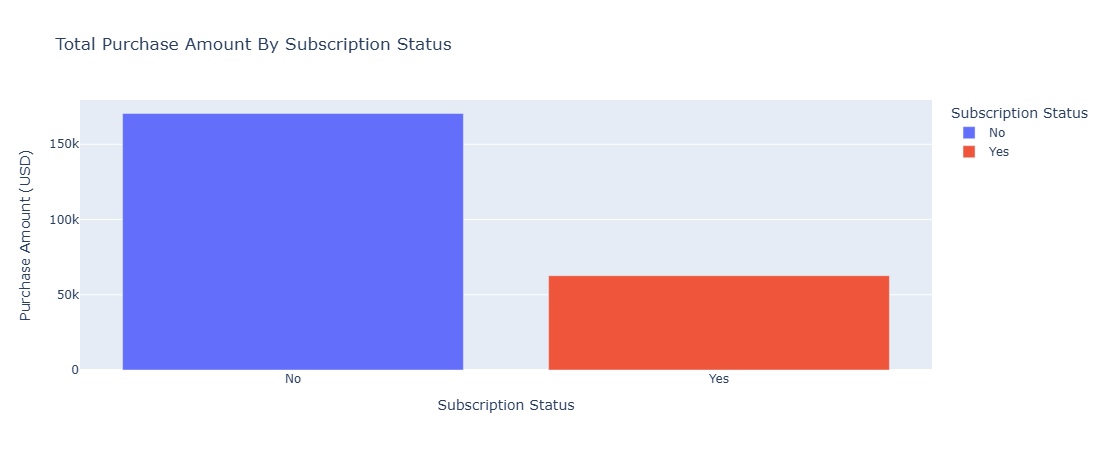

In [125]:
total_purchase_sub = df.groupby(['Subscription Status'])['Purchase Amount (USD)'].sum().reset_index()
px.bar(
    total_purchase_sub,
    x='Subscription Status',
    y='Purchase Amount (USD)',
    title='Total Purchase Amount By Subscription Status',
    width=800,
    height=450,
    color ='Subscription Status'
)